# Part 1:

- The plan has 100 coach seats, 20 first class seats
- We have 365 days to sell tickets before flight departs, 1 or 0 ticket per day
- Coach can be priced at $300 (65% probability of sale), $325 (45%), or $350 (30%)
- First class at $425 (8%) or $500 (4%)
- If first class sells out, coach sale prob increases by 4pp regardless of price
- Each coach ticket holder shows up with 95% chance probability, each first class at 97%
- If more than 100 coach passengers show up, bump to first class at $50/person if seats available, otherwise pay voucher for another flight at $425/person
- No overbooking is possible for first class
- Discount rate is 1/(1 + 0.17/365)

Allow coach to be oversold by 5 seats, so max coach tickets sold can be 105

Find optimal pricing policy, so which coach price and first class price to charge each day to maximize expected discounted profit

In [73]:
import numpy as np
from scipy.stats import binom
from matplotlib.colors import BoundaryNorm

choice_labels = [   #standardizing colors for future reference
    '$300C + $425F',
    '$300C + $500F',
    '$325C + $425F',
    '$325C + $500F',
    '$350C + $425F',
    '$350C + $500F',
    'No Sale + $425F',
    'No Sale + $500F'
]

cmap_standard = plt.cm.get_cmap('tab10', 8)

C:\Users\Owner\AppData\Local\Temp\ipykernel_20624\2922704893.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_standard = plt.cm.get_cmap('tab10', 8)


In [74]:
T = 365
coach_seats = 100
first_class_seats = 20
overbooking_limit = 5
max_coach_tix_sold = coach_seats + overbooking_limit

In [75]:
V = np.zeros((T+1, max_coach_tix_sold+1, first_class_seats+1)) #the 366x106x21 tensor dimension from class
U = np.zeros((T+1, max_coach_tix_sold+1, first_class_seats+1), dtype=int) #stores choices from class

In [76]:
high_coach_price = 350
high_coach_prob = 0.30
med_coach_price = 325
med_coach_prob = 0.45
low_coach_price = 300
low_coach_prob = 0.65
high_first_class_price = 500
high_first_class_prob = 0.04
low_first_class_price = 425
low_first_class_prob = 0.08

choices = [
    (low_coach_price, low_coach_prob, low_first_class_price, low_first_class_prob),
    (low_coach_price, low_coach_prob, high_first_class_price, high_first_class_prob),
    (med_coach_price, med_coach_prob, low_first_class_price, low_first_class_prob),
    (med_coach_price, med_coach_prob, high_first_class_price, high_first_class_prob),
    (high_coach_price, high_coach_prob, low_first_class_price, low_first_class_prob),
    (high_coach_price, high_coach_prob, high_first_class_price, high_first_class_prob)
]

choices

[(300, 0.65, 425, 0.08),
 (300, 0.65, 500, 0.04),
 (325, 0.45, 425, 0.08),
 (325, 0.45, 500, 0.04),
 (350, 0.3, 425, 0.08),
 (350, 0.3, 500, 0.04)]

In [77]:
coach_show_up_prob = 0.95
first_class_show_up_prob = 0.97
bump_to_fc_cost = 50
bump_off_plane_cost = 425
discount = 1/(1+0.17/365)
first_class_sold_out_boost = 0.04

Terminal Condition:

Finding V[365, c, f] for all possible c, f combinations

In [78]:
for c in range(max_coach_tix_sold+1): #for every possible number of coach tickets sold
    for f in range(first_class_seats+1): #"" first class tickets sold
        cost_expected = 0
        p_coach = binom.pmf(range(c+1), c, coach_show_up_prob) #probabilities of 0, 1, ..., c coach passengers showing up
        p_first_class = binom.pmf(range(f+1), f, first_class_show_up_prob) #"" of f first class passengers showing up
        for i in range(c+1): #for every possible number of coach passengers that show up
            for j in range(f+1): #"" first class passengers that show up
                p_ij = p_coach[i] * p_first_class[j] #joint probability from class
                overbooked_coach = max(0, i - coach_seats) #overbooked coach passengers witout a coach seat
                first_class_empty_seats = max(0, first_class_seats - j) #empty first class seats
                bumped_to_first_class = min(overbooked_coach, first_class_empty_seats) #passengers bumped from coach to first class at $50/person
                bumped_off_plane = overbooked_coach - bumped_to_first_class #passengers given vouchers to new flights at $425/person
                cost = bumped_to_first_class * bump_to_fc_cost + bumped_off_plane * bump_off_plane_cost #total cost of overbooking in one scenario
                cost_expected += p_ij * cost #expected cost of overbooking across every scenario
        V[T, c, f] = -cost_expected #trying to maximize profit, minimize costs

In [79]:
# V[365, 0, 0] #at last day, sold no coach or first class tix, expected cost
# V[365, 100, 20] #sold out, expected cost
# V[365, 105, 20] #overbooked coach by 5, sold out, expected cost is nonzero
V[365, 105, 15] #overbooked coach by 5, first class not sold out, expected cost is lower than previous check

-37.52470504591379

Bellman equation:

Loop backwards in time to find the value function at every possible state

In [80]:
for t in reversed(range(T)): #loop backwards in time, starting at 364 since terminal condition covers 365
    for c in range(max_coach_tix_sold+1): #can sell 105 tix
        for f in range(first_class_seats+1): #can't overbook first class
            coach_full = (c == max_coach_tix_sold) #if c = 105, coach is full, can't sell more
            first_class_full = (f == first_class_seats) #if f = 20, first class is full, can't sell more

            if coach_full and first_class_full:
                V[t, c, f] = discount * V[t+1, c, f] #no reward today because we can't sell any more tickets, discounted future value
                U[t, c, f] = 0 #can't sell
                continue

            best_profit = -np.inf 
            best_price_choice = 0

            for index, (coach_price, coach_prob, first_class_price, first_class_prob) in enumerate(choices): #for each of the 6 price combos
                prob_sell_coach = 0 if coach_full else coach_prob
                prob_sell_first_class = 0 if first_class_full else first_class_prob

                if first_class_full and not coach_full:
                    prob_sell_coach = min(1, prob_sell_coach + first_class_sold_out_boost) #increase of 4% chance of selling a coach ticket if first class is sold out

                coach_next_state = min(c+1, max_coach_tix_sold) #if we sell a coach ticket, next state is c+1, cannot > 105
                first_class_next_state = min(f+1, first_class_seats) #if we sell a first class ticket, next state is f+1, cannot > 20

                today_revenue = prob_sell_coach * coach_price + prob_sell_first_class * first_class_price #expected revenue from selling tickets today
                future_revenue = (
                    (1-prob_sell_coach) * (1-prob_sell_first_class) * V[t+1, c, f] + #sold no tickets
                    (prob_sell_coach) * (1-prob_sell_first_class) * V[t+1, coach_next_state, f] + #sold coach ticket only
                    (1-prob_sell_coach) * (prob_sell_first_class) * V[t+1, c, first_class_next_state ] + #sold first class ticket only
                    (prob_sell_coach) * (prob_sell_first_class) * V[t+1, coach_next_state, first_class_next_state] #sold both tickets
                )

                profit = today_revenue + discount * future_revenue

                if profit > best_profit:
                    best_profit = profit
                    best_price_choice = index + 1

            V[t, c, f] = best_profit
            U[t, c, f] = best_price_choice

In [81]:
round(V[0, 0, 0], 2) #expected profit if we start with no tickets sold on day 0 and follow optimal policy

41909.75

C:\Users\Owner\AppData\Local\Temp\ipykernel_20624\3609307292.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', 6)


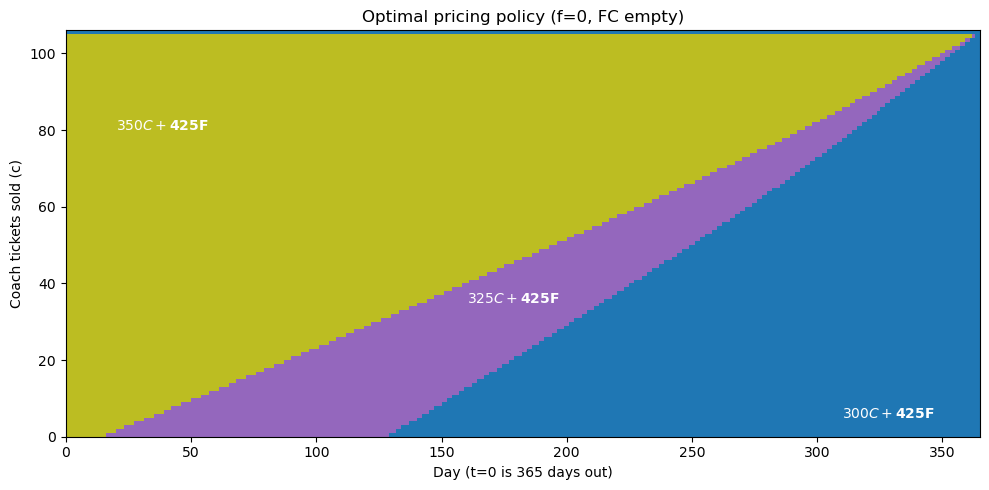

In [82]:
import matplotlib.pyplot as plt

labels = [f"${cp}C+${fp}F" for cp, _, fp, _ in choices]
cmap = plt.cm.get_cmap('tab10', 6)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.pcolormesh(U[:T, :, 0].T, cmap=cmap, vmin=0.5, vmax=6.5)

# Direct labels — (t, c) coordinates chosen to land inside each region
ax.text(20,  80, '$350C + $425F', fontsize=10, color='white', fontweight='bold')
ax.text(160, 35, '$325C + $425F', fontsize=10, color='white', fontweight='bold')
ax.text(310,  5, '$300C + $425F', fontsize=10, color='white', fontweight='bold')

ax.set_xlabel('Day (t=0 is 365 days out)')
ax.set_ylabel('Coach tickets sold (c)')
ax.set_title('Optimal pricing policy (f=0, FC empty)')
plt.tight_layout()
plt.show()

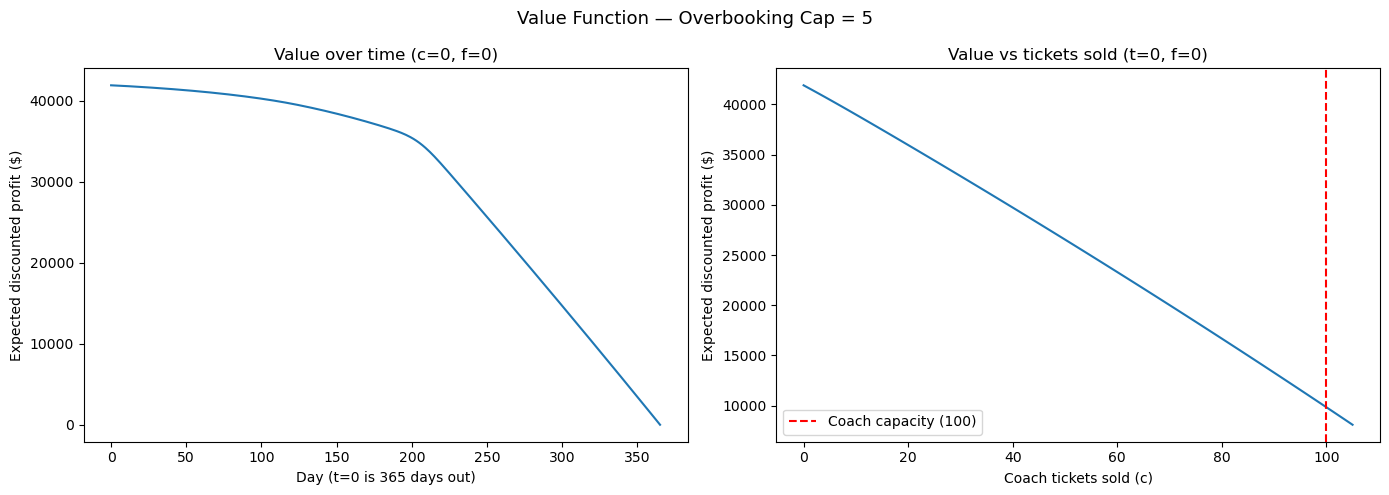

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: value function over time (no tickets sold yet)
axes[0].plot(range(T+1), V[:, 0, 0])
axes[0].set_xlabel('Day (t=0 is 365 days out)')
axes[0].set_ylabel('Expected discounted profit ($)')
axes[0].set_title('Value over time (c=0, f=0)')

# Right: value function as coach tickets sold increases (day 0)
axes[1].plot(range(max_coach_tix_sold+1), V[0, :, 0])
axes[1].axvline(x=coach_seats, color='red', linestyle='--', label='Coach capacity (100)')
axes[1].set_xlabel('Coach tickets sold (c)')
axes[1].set_ylabel('Expected discounted profit ($)')
axes[1].set_title('Value vs tickets sold (t=0, f=0)')
axes[1].legend()

plt.suptitle('Value Function — Overbooking Cap = 5', fontsize=13)
plt.tight_layout()
plt.show()

# Part 2: 

Now repeating Part 1 but allowing ourselves to overbook coach by 6, 7, 8, ..., 20 seats to find which overbooking policy leads to the largest profits

In [84]:
def simulate_policy(overbooking_limit):
    max_coach_tix_sold = coach_seats + overbooking_limit

    V = np.zeros((T+1, max_coach_tix_sold+1, first_class_seats+1)) #the 366x106x21 tensor dimension from class
    U = np.zeros((T+1, max_coach_tix_sold+1, first_class_seats+1), dtype=int) #stores choices from class

    #terminal condition:
    for c in range(max_coach_tix_sold+1): #for every possible number of coach tickets sold
        for f in range(first_class_seats+1): #"" first class tickets sold
            cost_expected = 0
            p_coach = binom.pmf(range(c+1), c, coach_show_up_prob) #probabilities of 0, 1, ..., c coach passengers showing up
            p_first_class = binom.pmf(range(f+1), f, first_class_show_up_prob) #"" of f first class passengers showing up
            for i in range(c+1): #for every possible number of coach passengers that show up
                for j in range(f+1): #"" first class passengers that show up
                    p_ij = p_coach[i] * p_first_class[j] #joint probability from class
                    overbooked_coach = max(0, i - coach_seats) #overbooked coach passengers witout a coach seat
                    first_class_empty_seats = max(0, first_class_seats - j) #empty first class seats
                    bumped_to_first_class = min(overbooked_coach, first_class_empty_seats) #passengers bumped from coach to first class at $50/person
                    bumped_off_plane = overbooked_coach - bumped_to_first_class #passengers given vouchers to new flights at $425/person
                    cost = bumped_to_first_class * bump_to_fc_cost + bumped_off_plane * bump_off_plane_cost #total cost of overbooking in one scenario
                    cost_expected += p_ij * cost #expected cost of overbooking across every scenario
            V[T, c, f] = -cost_expected #trying to maximize profit, minimize costs

    #bellman equation
    for t in reversed(range(T)): #loop backwards in time, starting at 364 since terminal condition covers 365
        for c in range(max_coach_tix_sold+1): #can sell 105 tix
            for f in range(first_class_seats+1): #can't overbook first class
                coach_full = (c == max_coach_tix_sold) #if c = 105, coach is full, can't sell more
                first_class_full = (f == first_class_seats) #if f = 20, first class is full, can't sell more

                if coach_full and first_class_full:
                    V[t, c, f] = discount * V[t+1, c, f] #no reward today because we can't sell any more tickets, discounted future value
                    U[t, c, f] = 0 #can't sell
                    continue

                best_profit = -np.inf 
                best_price_choice = 0

                for index, (coach_price, coach_prob, first_class_price, first_class_prob) in enumerate(choices): #for each of the 6 price combos
                    prob_sell_coach = 0 if coach_full else coach_prob
                    prob_sell_first_class = 0 if first_class_full else first_class_prob

                    if first_class_full and not coach_full:
                        prob_sell_coach = min(1, prob_sell_coach + first_class_sold_out_boost) #increase of 4% chance of selling a coach ticket if first class is sold out

                    coach_next_state = min(c+1, max_coach_tix_sold) #if we sell a coach ticket, next state is c+1, cannot > 105
                    first_class_next_state = min(f+1, first_class_seats) #if we sell a first class ticket, next state is f+1, cannot > 20

                    today_revenue = prob_sell_coach * coach_price + prob_sell_first_class * first_class_price #expected revenue from selling tickets today
                    future_revenue = (
                        (1-prob_sell_coach) * (1-prob_sell_first_class) * V[t+1, c, f] + #sold no tickets
                        (prob_sell_coach) * (1-prob_sell_first_class) * V[t+1, coach_next_state, f] + #sold coach ticket only
                        (1-prob_sell_coach) * (prob_sell_first_class) * V[t+1, c, first_class_next_state ] + #sold first class ticket only
                        (prob_sell_coach) * (prob_sell_first_class) * V[t+1, coach_next_state, first_class_next_state] #sold both tickets
                    )

                    profit = today_revenue + discount * future_revenue

                    if profit > best_profit:
                        best_profit = profit
                        best_price_choice = index + 1

                V[t, c, f] = best_profit
                U[t, c, f] = best_price_choice

    return V, U, round(V[0, 0, 0], 2)

In [85]:
simulate_policy(5) #checking for answer we found earlier: 41909.75

(array([[[ 4.19097485e+04,  4.15793070e+04,  4.12437377e+04, ...,
           3.49116616e+04,  3.44650101e+04,  3.40156879e+04],
         [ 4.16271896e+04,  4.12965480e+04,  4.09607759e+04, ...,
           3.46113655e+04,  3.41637817e+04,  3.37136298e+04],
         [ 4.13424046e+04,  4.10115685e+04,  4.06756004e+04, ...,
           3.43101662e+04,  3.38617488e+04,  3.34108518e+04],
         ...,
         [ 8.79549530e+03,  8.46311184e+03,  8.12556736e+03, ...,
           1.47868866e+03,  9.89926822e+02,  4.95619355e+02],
         [ 8.44641702e+03,  8.11403356e+03,  7.77648909e+03, ...,
           1.12960825e+03,  6.40830593e+02,  1.46413724e+02],
         [ 8.09679680e+03,  7.76441334e+03,  7.42686886e+03, ...,
           7.79987559e+02,  2.91204933e+02, -2.03270270e+02]],
 
        [[ 4.19012191e+04,  4.15710996e+04,  4.12357855e+04, ...,
           3.49107689e+04,  3.44643068e+04,  3.40151369e+04],
         [ 4.16192146e+04,  4.12888941e+04,  4.09533760e+04, ...,
           3.46106516

In [86]:
for i in range(5, 21): #from 5 to 20, the range of overbooking limits to check
    V, U, expected_profit = simulate_policy(i) #grab the expected profit for each overbooking limit
    print(f"Overbooking limit: {i}, Expected profit: {expected_profit}")

Overbooking limit: 5, Expected profit: 41909.75
Overbooking limit: 6, Expected profit: 42039.02
Overbooking limit: 7, Expected profit: 42117.95
Overbooking limit: 8, Expected profit: 42157.77
Overbooking limit: 9, Expected profit: 42171.35
Overbooking limit: 10, Expected profit: 42169.24
Overbooking limit: 11, Expected profit: 42158.86
Overbooking limit: 12, Expected profit: 42144.91
Overbooking limit: 13, Expected profit: 42130.13
Overbooking limit: 14, Expected profit: 42115.88
Overbooking limit: 15, Expected profit: 42102.78
Overbooking limit: 16, Expected profit: 42091.04
Overbooking limit: 17, Expected profit: 42080.72
Overbooking limit: 18, Expected profit: 42071.78
Overbooking limit: 19, Expected profit: 42064.15
Overbooking limit: 20, Expected profit: 42057.69


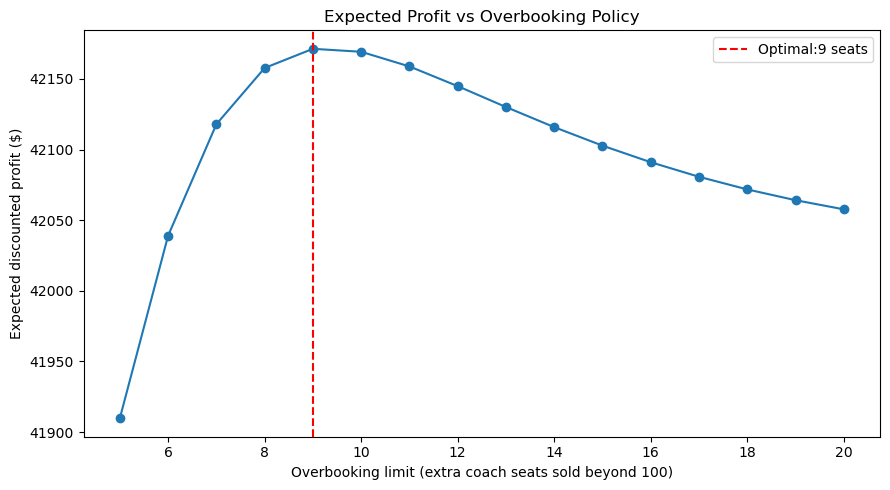

Optimal overbooking limit: 9 seats
Optimal expected profit: $42,171.35


In [87]:
overbooking_range = range(5, 21)
profits = [simulate_policy(ob)[2] for ob in overbooking_range]

plt.figure(figsize=(9, 5))
plt.plot(overbooking_range, profits, marker='o')
plt.axvline(x=overbooking_range[profits.index(max(profits))], color='red', linestyle='--', label=f'Optimal:{overbooking_range[profits.index(max(profits))]} seats')
plt.xlabel('Overbooking limit (extra coach seats sold beyond 100)')
plt.ylabel('Expected discounted profit ($)')
plt.title('Expected Profit vs Overbooking Policy')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal overbooking limit: {overbooking_range[profits.index(max(profits))]} seats")
print(f"Optimal expected profit: ${max(profits):,.2f}")

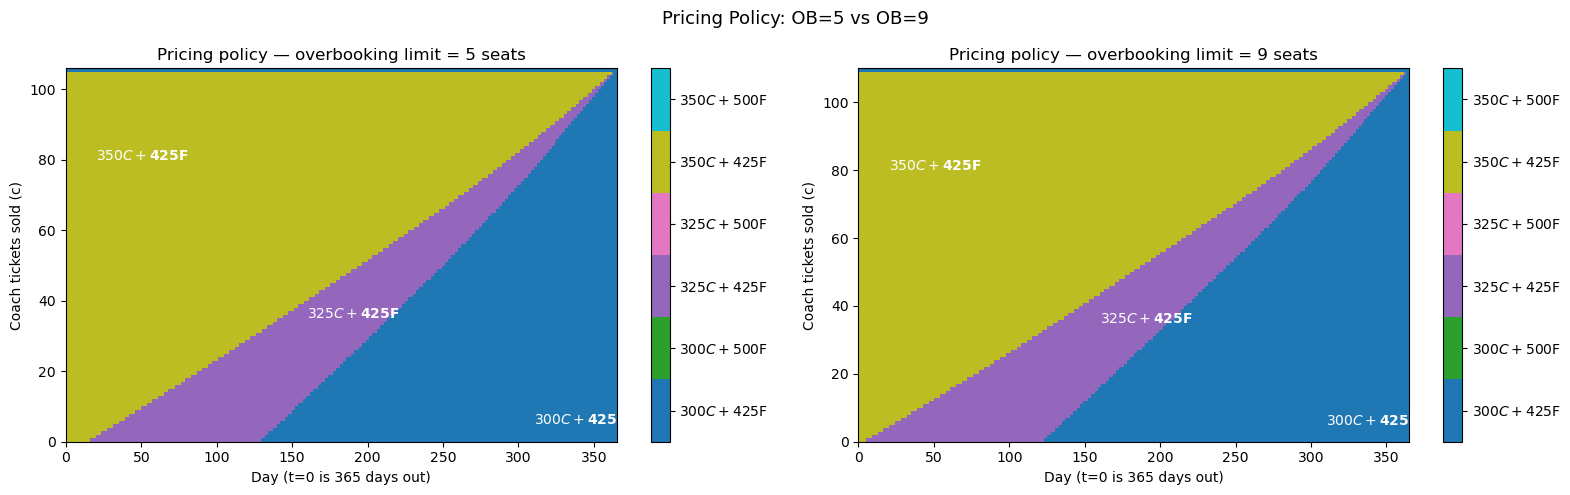

In [88]:
optimal_ob = 9

V5, U5, _ = simulate_policy(5)
V_opt, U_opt, _ = simulate_policy(optimal_ob)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, U_plot, ob in zip(axes, [U5, U_opt], [5, optimal_ob]):
    im = ax.pcolormesh(U_plot[:T, :, 0].T, cmap=cmap, vmin=0.5, vmax=6.5)
    cbar = fig.colorbar(im, ax=ax, ticks=range(1, 7))
    cbar.ax.set_yticklabels(labels)
    ax.text(20,  80, '$350C + $425F', fontsize=10, color='white', fontweight='bold')
    ax.text(160, 35, '$325C + $425F', fontsize=10, color='white', fontweight='bold')
    ax.text(310,  5, '$300C + $425F', fontsize=10, color='white', fontweight='bold')
    ax.set_xlabel('Day (t=0 is 365 days out)')
    ax.set_ylabel('Coach tickets sold (c)')
    ax.set_title(f'Pricing policy — overbooking limit = {ob} seats')

plt.suptitle('Pricing Policy: OB=5 vs OB=9', fontsize=13)
plt.tight_layout()
plt.show()

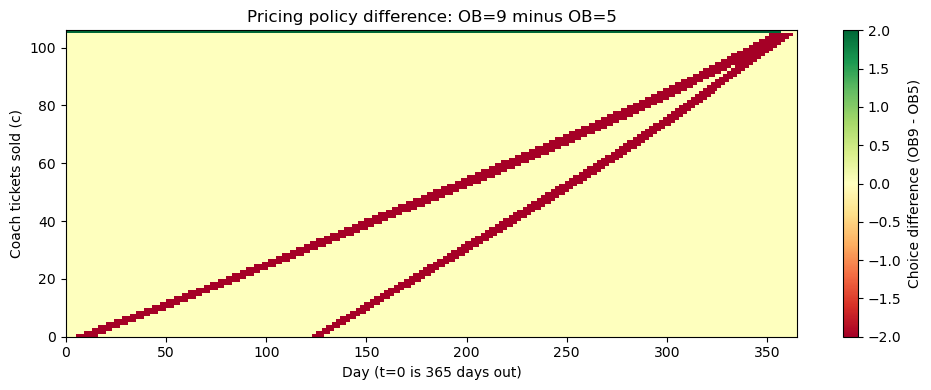

In [89]:
min_c = min(U5.shape[1], U_opt.shape[1])

diff = U_opt[:T, :min_c, 0] - U5[:T, :min_c, 0]

plt.figure(figsize=(10, 4))
plt.pcolormesh(diff.T, cmap='RdYlGn', vmin=-2, vmax=2)
plt.colorbar(label='Choice difference (OB9 - OB5)')
plt.xlabel('Day (t=0 is 365 days out)')
plt.ylabel('Coach tickets sold (c)')
plt.title('Pricing policy difference: OB=9 minus OB=5')
plt.tight_layout()
plt.show()

Interpretation: The yellow shaded regions show where both policies (allowing up to 5, 9 overbooked coach seats) choose the same price combination to offer. The red shaded regions, ending up as two diagonal lines, show where the two policies differ. These are indicating slightly different pricing decisions, which end up as the boundaries in the previous graph from $350 and $325 pricing regions. So the new optimal overbooking policy at 9 seats overbooked chooses a lower coach price at these boundary states. With 4 more tickets to sell, the new policy is less scarce at these red shaded states, so it is optimal to drop to the medium price a little longer.

The optimal overbooking policy comes almost entirely from seeling 4 more tickets, not necessarily repricing. The two policies (5, 9 overbooked coach seats) are pretty identical in how they price day to day. 

# Part 3: 

We now have the option to sell no coach tickets on a day if we want. So now, there are 4 choices for coach: LP, MP, HP, no sale.

Airline will never sell more than 130 seats in coach.

In [90]:
T = 365
coach_seats = 100
first_class_seats = 20
overbooking_limit = 30
max_coach_tix_sold = coach_seats + overbooking_limit
max_coach_tix_sold #check

130

In [91]:
V = np.zeros((T+1, max_coach_tix_sold+1, first_class_seats+1)) #the 366x131x21 tensor dimension now being able to book up to 30 extra coach seats
U = np.zeros((T+1, max_coach_tix_sold+1, first_class_seats+1), dtype=int) #stores choices from class

In [92]:
V.shape

(366, 131, 21)

In [93]:
high_coach_price = 350
high_coach_prob = 0.30
med_coach_price = 325
med_coach_prob = 0.45
low_coach_price = 300
low_coach_prob = 0.65
no_coach_price = 0
no_coach_prob = 0
high_first_class_price = 500
high_first_class_prob = 0.04
low_first_class_price = 425
low_first_class_prob = 0.08

choices = [
    (low_coach_price, low_coach_prob, low_first_class_price, low_first_class_prob),
    (low_coach_price, low_coach_prob, high_first_class_price, high_first_class_prob),
    (med_coach_price, med_coach_prob, low_first_class_price, low_first_class_prob),
    (med_coach_price, med_coach_prob, high_first_class_price, high_first_class_prob),
    (high_coach_price, high_coach_prob, low_first_class_price, low_first_class_prob),
    (high_coach_price, high_coach_prob, high_first_class_price, high_first_class_prob),
    (no_coach_price, no_coach_prob, low_first_class_price, low_first_class_prob),
    (no_coach_price, no_coach_prob, high_first_class_price, high_first_class_prob)
]

choices

[(300, 0.65, 425, 0.08),
 (300, 0.65, 500, 0.04),
 (325, 0.45, 425, 0.08),
 (325, 0.45, 500, 0.04),
 (350, 0.3, 425, 0.08),
 (350, 0.3, 500, 0.04),
 (0, 0, 425, 0.08),
 (0, 0, 500, 0.04)]

In [94]:
coach_show_up_prob = 0.95
first_class_show_up_prob = 0.97
bump_to_fc_cost = 50
bump_off_plane_cost = 425
discount = 1/(1+0.17/365)
first_class_sold_out_boost = 0.04

Terminal Condition copy and pasted from above

In [95]:
for c in range(max_coach_tix_sold+1): #for every possible number of coach tickets sold
    for f in range(first_class_seats+1): #"" first class tickets sold
        cost_expected = 0
        p_coach = binom.pmf(range(c+1), c, coach_show_up_prob) #probabilities of 0, 1, ..., c coach passengers showing up
        p_first_class = binom.pmf(range(f+1), f, first_class_show_up_prob) #"" of f first class passengers showing up
        for i in range(c+1): #for every possible number of coach passengers that show up
            for j in range(f+1): #"" first class passengers that show up
                p_ij = p_coach[i] * p_first_class[j] #joint probability from class
                overbooked_coach = max(0, i - coach_seats) #overbooked coach passengers witout a coach seat
                first_class_empty_seats = max(0, first_class_seats - j) #empty first class seats
                bumped_to_first_class = min(overbooked_coach, first_class_empty_seats) #passengers bumped from coach to first class at $50/person
                bumped_off_plane = overbooked_coach - bumped_to_first_class #passengers given vouchers to new flights at $425/person
                cost = bumped_to_first_class * bump_to_fc_cost + bumped_off_plane * bump_off_plane_cost #total cost of overbooking in one scenario
                cost_expected += p_ij * cost #expected cost of overbooking across every scenario
        V[T, c, f] = -cost_expected #trying to maximize profit, minimize costs

Bellman copy and pasted from above

In [96]:
for t in reversed(range(T)): #loop backwards in time, starting at 364 since terminal condition covers 365
    for c in range(max_coach_tix_sold+1): #can sell 105 tix
        for f in range(first_class_seats+1): #can't overbook first class
            coach_full = (c == max_coach_tix_sold) #if c = 105, coach is full, can't sell more
            first_class_full = (f == first_class_seats) #if f = 20, first class is full, can't sell more

            if coach_full and first_class_full:
                V[t, c, f] = discount * V[t+1, c, f] #no reward today because we can't sell any more tickets, discounted future value
                U[t, c, f] = 0 #can't sell
                continue

            best_profit = -np.inf 
            best_price_choice = 0

            for index, (coach_price, coach_prob, first_class_price, first_class_prob) in enumerate(choices): #for each of the 6 price combos
                prob_sell_coach = 0 if coach_full else coach_prob
                prob_sell_first_class = 0 if first_class_full else first_class_prob

                if first_class_full and not coach_full and coach_prob > 0:
                    prob_sell_coach = min(1, prob_sell_coach + first_class_sold_out_boost) #increase of 4% chance of selling a coach ticket if first class is sold out

                coach_next_state = min(c+1, max_coach_tix_sold) #if we sell a coach ticket, next state is c+1, cannot > 105
                first_class_next_state = min(f+1, first_class_seats) #if we sell a first class ticket, next state is f+1, cannot > 20

                today_revenue = prob_sell_coach * coach_price + prob_sell_first_class * first_class_price #expected revenue from selling tickets today
                future_revenue = (
                    (1-prob_sell_coach) * (1-prob_sell_first_class) * V[t+1, c, f] + #sold no tickets
                    (prob_sell_coach) * (1-prob_sell_first_class) * V[t+1, coach_next_state, f] + #sold coach ticket only
                    (1-prob_sell_coach) * (prob_sell_first_class) * V[t+1, c, first_class_next_state ] + #sold first class ticket only
                    (prob_sell_coach) * (prob_sell_first_class) * V[t+1, coach_next_state, first_class_next_state] #sold both tickets
                )

                profit = today_revenue + discount * future_revenue

                if profit > best_profit:
                    best_profit = profit
                    best_price_choice = index + 1

            V[t, c, f] = best_profit
            U[t, c, f] = best_price_choice

In [97]:
round(V[0, 0, 0], 2) #expected profit if we start with no tickets sold on day 0 and follow optimal policy

42177.14

% of states where no-sale is chosen: 7.0%


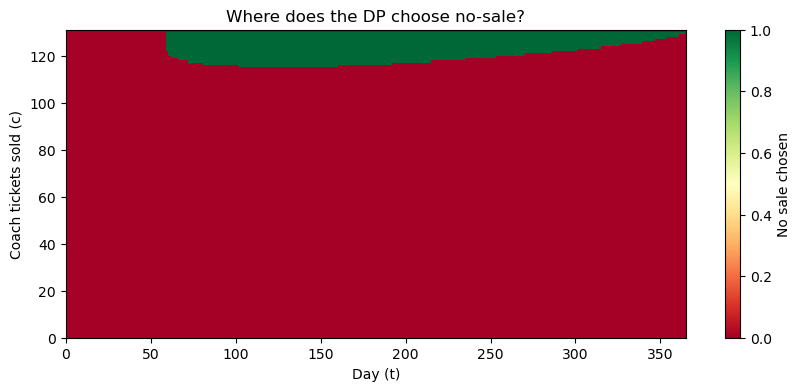

In [98]:
no_sale_mask = (U[:T, :, 0] == 7) | (U[:T, :, 0] == 8)
print(f"% of states where no-sale is chosen: {no_sale_mask.mean()*100:.1f}%")

plt.figure(figsize=(10, 4))
plt.pcolormesh(no_sale_mask.T, cmap='RdYlGn')
plt.xlabel('Day (t)')
plt.ylabel('Coach tickets sold (c)')
plt.title('Where does the DP choose no-sale?')
plt.colorbar(label='No sale chosen')
plt.show()

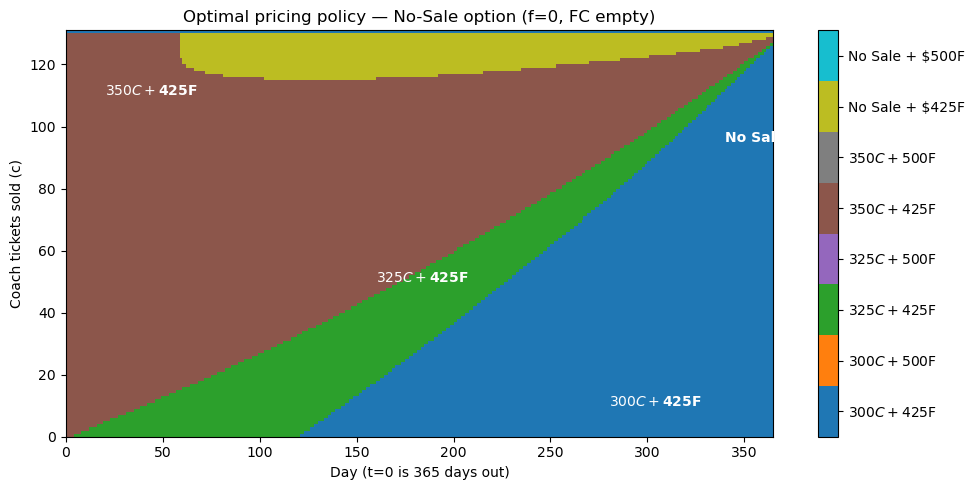

In [99]:
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.pcolormesh(U[:T, :, 0].T, cmap=cmap_standard, vmin=0.5, vmax=8.5)
cbar = fig.colorbar(im, ax=ax, ticks=range(1, 9))
cbar.ax.set_yticklabels(choice_labels)
ax.set_xlabel('Day (t=0 is 365 days out)')
ax.set_ylabel('Coach tickets sold (c)')
ax.set_title('Optimal pricing policy — No-Sale option (f=0, FC empty)')

# direct labels — adjust coordinates after seeing the plot
ax.text(20,  110, '$350C + $425F', fontsize=10, color='white', fontweight='bold')
ax.text(160,  50, '$325C + $425F', fontsize=10, color='white', fontweight='bold')
ax.text(280,  10, '$300C + $425F', fontsize=10, color='white', fontweight='bold')
ax.text(340,  95, 'No Sale',        fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

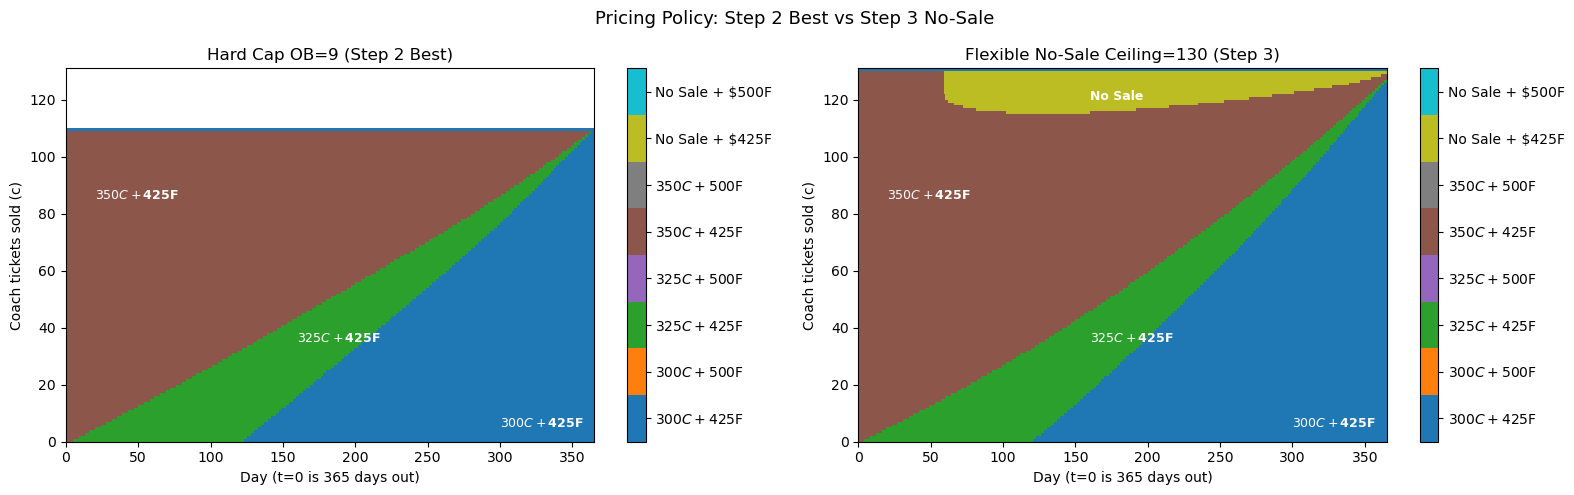

In [110]:
V_ob9, U_ob9, _ = simulate_policy(9)

# Match both panels to the same y-height (Step 3 max coach tickets sold),
# but leave OB=9 uncolored above its true ceiling (109).
target_height = U[:T, :, 0].shape[1]
left_height = U_ob9[:T, :, 0].shape[1]

U_ob9_padded = np.full((T, target_height), np.nan)
U_ob9_padded[:, :left_height] = U_ob9[:T, :, 0]

cmap_compare = cmap_standard.copy()
cmap_compare.set_bad(color='white')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, U_plot, title in zip(
    axes,
    [U_ob9_padded, U[:T, :, 0]],
    ['Hard Cap OB=9 (Step 2 Best)', 'Flexible No-Sale Ceiling=130 (Step 3)']
):
    im = ax.pcolormesh(U_plot.T, cmap=cmap_compare, vmin=0.5, vmax=8.5)
    cbar = fig.colorbar(im, ax=ax, ticks=range(1, 9))
    cbar.ax.set_yticklabels(choice_labels)
    ax.text(20, 85, '$350C + $425F', fontsize=9, color='white', fontweight='bold')
    ax.text(160, 35, '$325C + $425F', fontsize=9, color='white', fontweight='bold')
    ax.text(300, 5, '$300C + $425F', fontsize=9, color='white', fontweight='bold')
    ax.set_xlabel('Day (t=0 is 365 days out)')
    ax.set_ylabel('Coach tickets sold (c)')
    ax.set_ylim(0, target_height)
    ax.set_title(title)

# add no-sale label only on step 3 plot (second axis)
axes[1].text(160, 120, 'No Sale', fontsize=9, color='white', fontweight='bold')

plt.suptitle('Pricing Policy: Step 2 Best vs Step 3 No-Sale', fontsize=13)
plt.tight_layout()
plt.show()

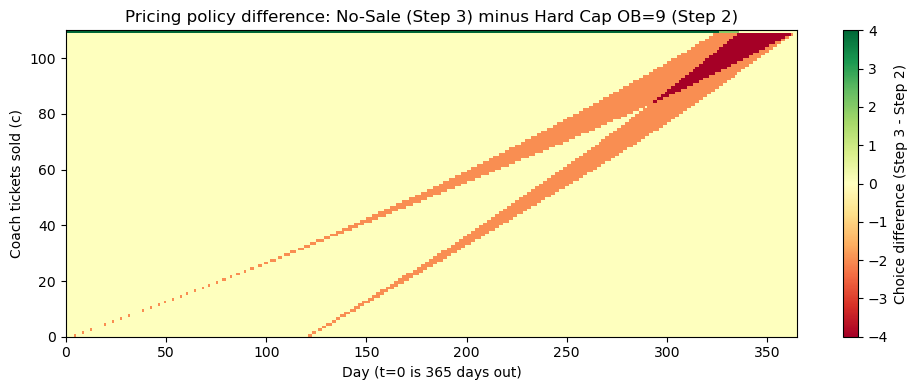

In [107]:
min_c = min(U_ob9.shape[1], U.shape[1])
diff = U[:T, :min_c, 0] - U_ob9[:T, :min_c, 0]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.pcolormesh(diff.T, cmap='RdYlGn', vmin=-4, vmax=4)
plt.colorbar(im, label='Choice difference (Step 3 - Step 2)')
ax.set_xlabel('Day (t=0 is 365 days out)')
ax.set_ylabel('Coach tickets sold (c)')
ax.set_title('Pricing policy difference: No-Sale (Step 3) minus Hard Cap OB=9 (Step 2)')
plt.tight_layout()
plt.show()

Interpretation: Yellow still remains the unchanged policies when comparing Part 3 and 2's price combinations. Still in most states, the no-sale option for Part 3 doesn't change anything, where the dynamic program sells at the same price as before. 

There's now 2 different price combinations that Part 3 differs from than Part 2. The orange difference is the same shift we saw comparing Part 1 and Part 2. Part 3 chooses a slightly lower coach price than Part 2 to avoid overbooking costs.

The new region is the top right, red shaded area. So now, as you approach takeoff with already many tickets sold in both coach and first class, Part 3 is choosing either a lower or no sale option to avoid overbooking costs incurred in Part 2.

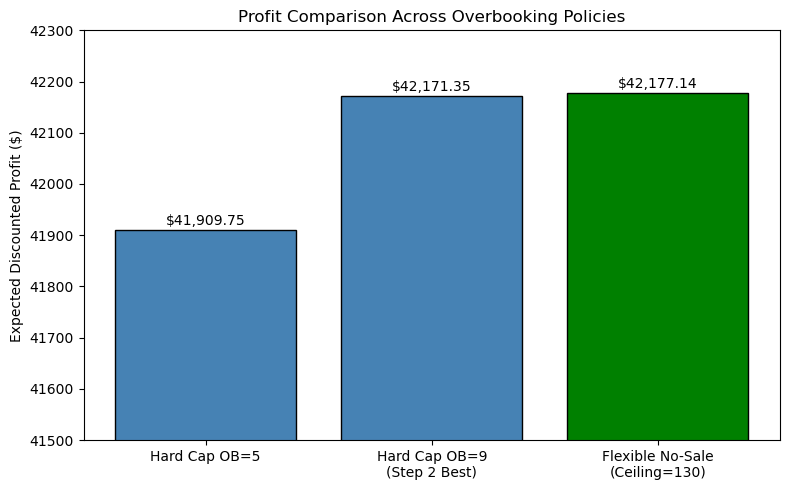

In [100]:
policies = ['Hard Cap OB=5', 'Hard Cap OB=9\n(Step 2 Best)', 'Flexible No-Sale\n(Ceiling=130)']
profits_3 = [41909.75, 42171.35, 42177.14]

plt.figure(figsize=(8, 5))
bars = plt.bar(policies, profits_3, color=['steelblue', 'steelblue', 'green'], edgecolor='black')
plt.ylim(41500, 42300)
plt.ylabel('Expected Discounted Profit ($)')
plt.title('Profit Comparison Across Overbooking Policies')
for bar, profit in zip(bars, profits_3):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'${profit:,.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

- Overbooking policy (5): $41,909.75
- Overbooking policy (9): $42,171.35
- No-sale option, overbooking policy (30): $42,177.14